<a href="https://colab.research.google.com/github/iZevro/ITCS-3162/blob/Lab-4/lab_04_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 — Example: Data Exploration with Palmer Penguins

**ITCS 3162 — Introduction to Data Mining**
**Companion to Zybooks Chapter 4 (Data Exploration)**

Once your data is wrangled (Lab 3), the next step is **exploration**: getting a feel for the shape of the data through summary statistics and visualization. This is sometimes called **EDA (Exploratory Data Analysis)**.

We use the **Palmer Penguins dataset** — measurements of three penguin species from islands in the Palmer Archipelago, Antarctica. It's a friendly stand-in for the more famous (but overused) iris dataset.

## Learning objectives
- Summarize numeric and categorical variables with descriptive statistics
- Visualize **distributions** (histograms, KDE, boxplots, violin plots)
- Visualize **relationships** (scatter plots, pair plots, heatmaps)
- Compare groups across categorical variables
- Spot outliers, skew, and missing data visually
- Develop EDA intuition — what to look for, in what order


## 1. Load and quick-look


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = sns.load_dataset("penguins")
print("Shape:", df.shape)
df.head()

Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Column dictionary

| Column | Type | Notes |
|---|---|---|
| `species` | str | Adelie, Chinstrap, or Gentoo |
| `island` | str | Torgersen, Biscoe, or Dream |
| `bill_length_mm` | float | Length of bill |
| `bill_depth_mm` | float | Depth of bill |
| `flipper_length_mm` | float | Flipper length |
| `body_mass_g` | float | Body mass in grams |
| `sex` | str | Male or Female (some missing) |


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [3]:
# Missing values by column
df.isna().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


A few rows have missing values, mostly in `sex`. For exploration we'll keep them and let plots handle them; for modeling we'd impute or drop.


## 2. Numeric summaries


In [4]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


Quick read of this table:
- `body_mass_g` ranges from ~2,700g to ~6,300g — that's a 2.3× spread, big enough that it'll dominate any distance-based model unless we scale it (preview of Lab 5).
- Bill length and bill depth have very different scales but similar ranges within themselves.
- The medians (50%) are close to the means, suggesting roughly symmetric distributions — we'll confirm with a histogram.


In [5]:
# Summary by species — much more informative than overall summary
df.groupby("species").describe()["body_mass_g"].round(1)

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Adelie,151.0,3700.7,458.6,2850.0,3350.0,3700.0,4000.0,4775.0
Chinstrap,68.0,3733.1,384.3,2700.0,3487.5,3700.0,3950.0,4800.0
Gentoo,123.0,5076.0,504.1,3950.0,4700.0,5000.0,5500.0,6300.0


Gentoo are noticeably heavier — almost a full kilogram heavier than the other two species. That's a strong, exploitable signal for classification.


## 3. Categorical summaries


In [6]:
# Species counts
print(df["species"].value_counts())
print()
# Island counts
print(df["island"].value_counts())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


In [8]:
# A 2-way table — which species live on which islands?
pd.crosstab(df["species"], df["island"])

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


Interesting: Gentoo are only on Biscoe, Chinstrap only on Dream, Adelie on all three islands. This means **island is a strong predictor of species** — sometimes a categorical variable carries more signal than any numeric measurement.


## 4. Visualizing distributions

### Histogram + KDE — one continuous variable


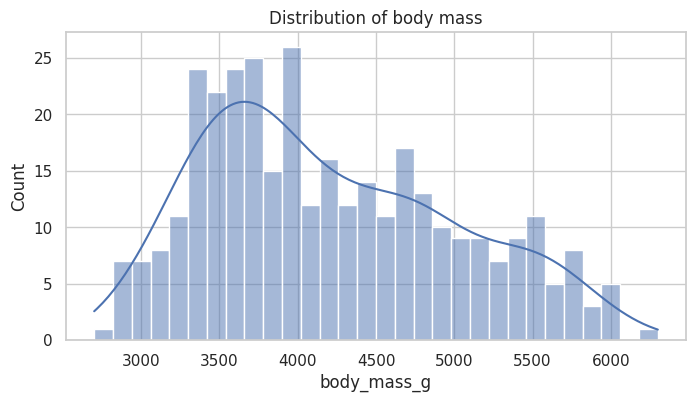

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x="body_mass_g", kde=True, bins=30, ax=ax)
ax.set_title("Distribution of body mass")
plt.show()

The clear **bimodality** in body mass is a giant clue — there are at least two subpopulations mixed together. The grouping by species will likely separate them.


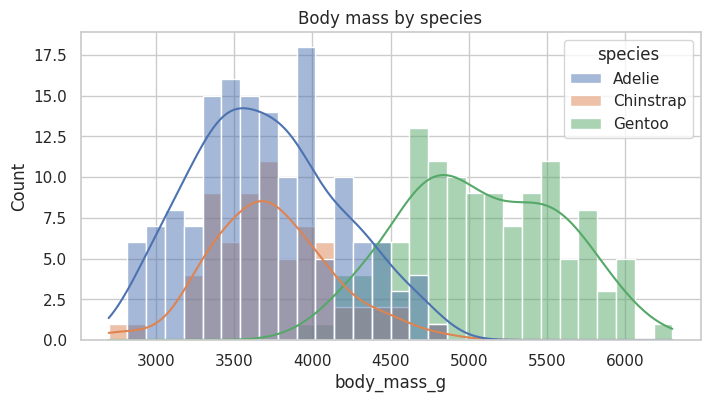

In [10]:
# Same histogram, split by species
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x="body_mass_g", hue="species", kde=True, bins=30, ax=ax)
ax.set_title("Body mass by species")
plt.show()

Confirmed: the bimodality is Gentoo vs. (Adelie + Chinstrap).


### Boxplot — compare distributions across groups


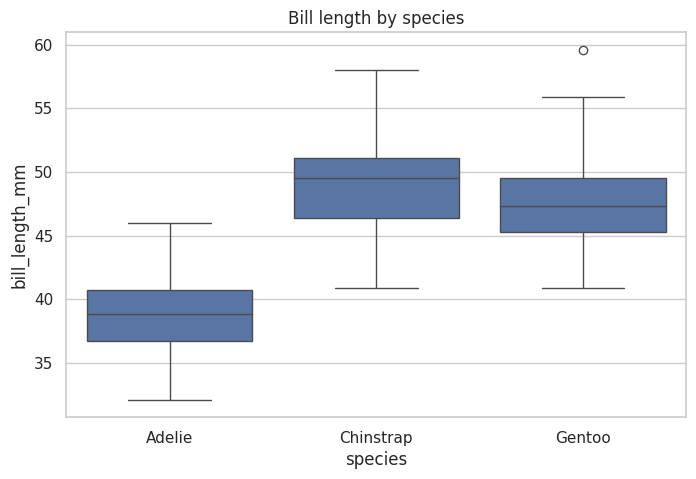

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="species", y="bill_length_mm", ax=ax)
ax.set_title("Bill length by species")
plt.show()

Reading a boxplot:
- **Box** = 25th to 75th percentile (the IQR — interquartile range)
- **Line in the box** = median
- **Whiskers** = roughly 1.5×IQR beyond the box
- **Points** beyond = outliers

Bill length cleanly separates Adelie (short) from Chinstrap (long) — but doesn't help distinguish Chinstrap from Gentoo.


### Violin plot — boxplot + distribution shape


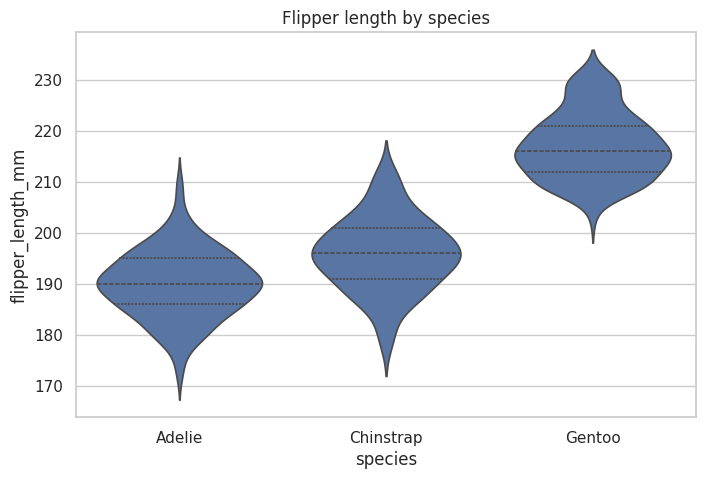

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df, x="species", y="flipper_length_mm", ax=ax, inner="quartile")
ax.set_title("Flipper length by species")
plt.show()

Violin = mirrored KDE. Gentoo have noticeably longer flippers; the other two overlap heavily.


## 5. Visualizing relationships


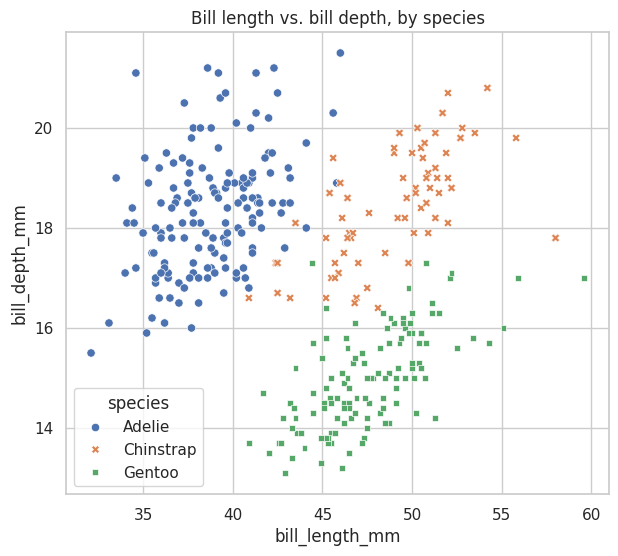

In [13]:
# Scatter: two numeric variables, colored by species
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species", style="species", ax=ax)
ax.set_title("Bill length vs. bill depth, by species")
plt.show()

These two features alone almost perfectly separate the three species. **A single well-chosen pair of features can be more useful than a fancy model.**

Note the **Simpson's paradox** here: if you fit a line to all penguins ignoring species, bill_length and bill_depth are *negatively* correlated. Within each species, they're *positively* correlated.


### Pair plot — every pair at once


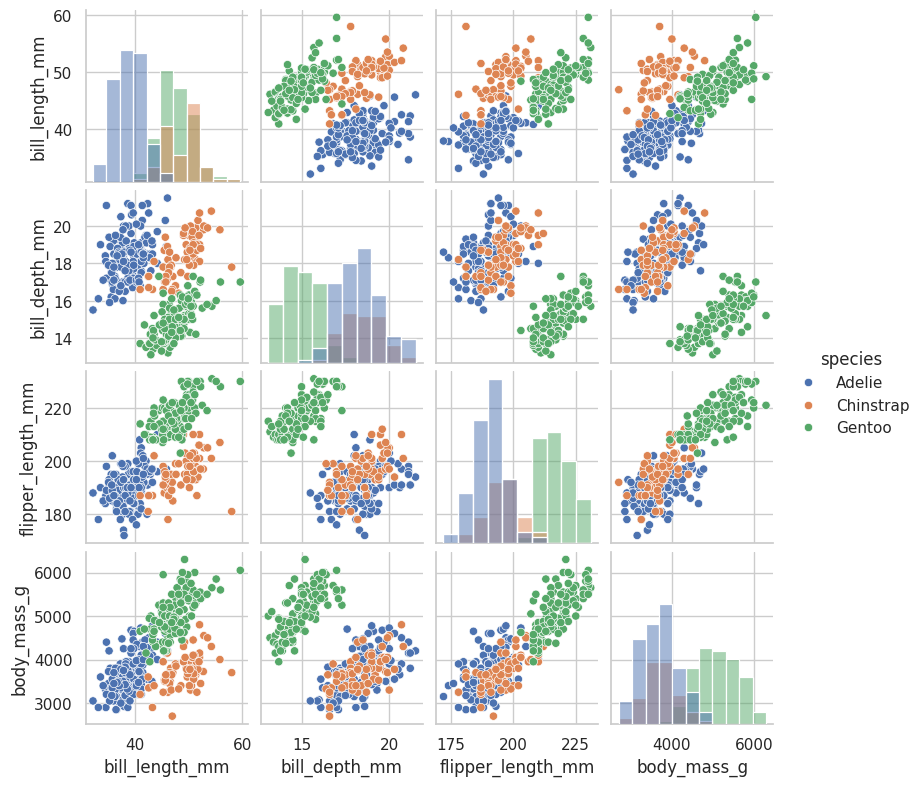

In [14]:
# A "fishing expedition" plot — useful for first-look exploration
sns.pairplot(df.dropna(), hue="species", diag_kind="hist", height=2)
plt.show()

The diagonal shows the distribution of each feature; off-diagonals show pairwise scatter. Pair plots get crowded with more than ~6 features, but for small datasets they give you a one-glance feel for the whole structure.


### Correlation heatmap — pairwise linear correlation


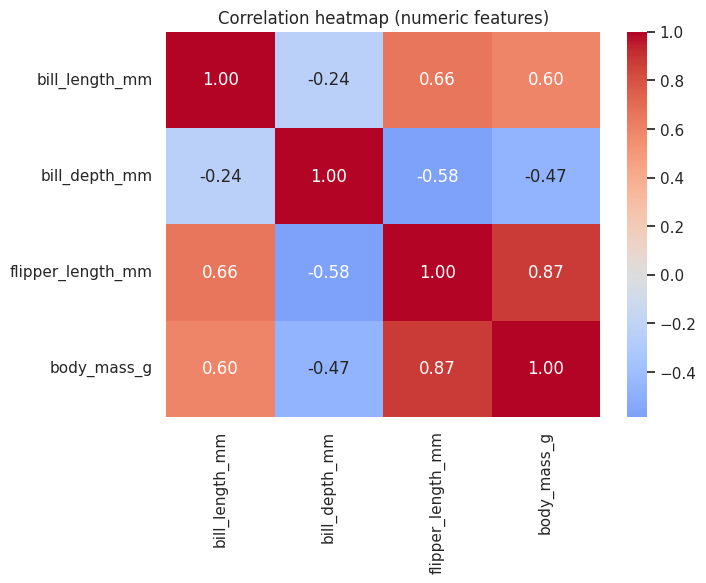

In [15]:
numeric = df.select_dtypes("number")
corr = numeric.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation heatmap (numeric features)")
plt.show()

Flipper length and body mass have correlation ~0.87 — they carry overlapping information. If we built a model with both, one might be redundant. This kind of insight motivates **dimensionality reduction** (Lab 5).


## 6. Outlier scan

Boxplots already showed us a few outliers. A complementary view — **z-scores**:


In [17]:
from scipy import stats

numeric_clean = df.dropna(subset=numeric.columns)
z = np.abs(stats.zscore(numeric_clean[numeric.columns]))
outliers = numeric_clean[(z > 3).any(axis=1)]
print(f"Rows with |z| > 3 in any feature: {len(outliers)}")
outliers

Rows with |z| > 3 in any feature: 0


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex


Zero rows — this dataset is clean of extreme outliers (after any data quality issues). Real-world datasets rarely look this tidy.


## 7. The EDA mindset

A useful order of operations for any new dataset:

1. **Shape, dtypes, head** → what are we looking at?
2. **Missing values** → where? how much?
3. **Numeric describe** → ranges, means, skew hints
4. **Categorical value counts** → balance, dominant levels
5. **Univariate plots** → histograms for each numeric, bars for each categorical
6. **Bivariate plots** → scatters of suspected relationships, boxplots across groups
7. **Multivariate** → pair plot, correlation heatmap
8. **Document the surprises** → write down anything unexpected

The goal isn't to make every possible plot — it's to **build intuition before modeling**. Surprises you find now become features (or red flags) later.


## Summary

Tools to remember:

| Question | Tool |
|---|---|
| What does this variable look like? | `histplot`, `kdeplot`, `describe()` |
| How do groups compare? | `boxplot`, `violinplot`, `groupby().agg()` |
| Are two variables related? | `scatterplot`, `corr()`, `heatmap` |
| Big picture of many features? | `pairplot`, correlation heatmap |
| Are there outliers? | `boxplot`, z-scores, manual filtering |

Open **`lab_04_exercise.ipynb`** to explore world stock market indices on your own.
